# Can ASO Atlas be used to train ASOptimizer?

**Quick analysis to answer key questions about dataset compatibility.**

In [1]:
import sys
sys.path.insert(0, 'aso_atlas')
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load data
atlas = pd.read_pickle('aso_atlas/data/aso_atlas.pkl')
asopt = pd.read_csv('ASOptimizer/dataset/experiments_with_smiles.csv', low_memory=False)
print(f"ASO Atlas: {len(atlas):,} records | ASOptimizer: {len(asopt):,} records")

ASO Atlas: 190,927 records | ASOptimizer: 36,890 records


---
## Q1: Do both datasets measure the same thing?

**Answer: Yes.** Both measure ASO knockdown efficacy (% inhibition of target mRNA).

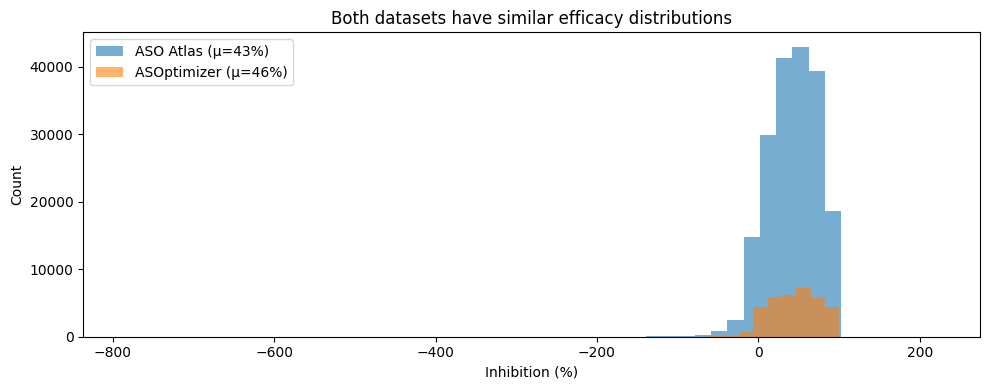

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(atlas['inhibition_percent'].dropna(), bins=50, alpha=0.6, label=f"ASO Atlas (μ={atlas['inhibition_percent'].mean():.0f}%)")
ax.hist(asopt['Inhibition(%)'].dropna(), bins=50, alpha=0.6, label=f"ASOptimizer (μ={asopt['Inhibition(%)'].mean():.0f}%)")
ax.set_xlabel('Inhibition (%)')
ax.set_ylabel('Count')
ax.legend()
ax.set_title('Both datasets have similar efficacy distributions')
plt.tight_layout()
plt.show()

---
## Q2: How much overlap is there?

**Answer: Significant.** 89% of ASOptimizer sequences appear in ASO Atlas.

In [3]:
atlas_seqs = set(atlas['aso_sequence_5_to_3'].str.upper())
asopt_seqs = set(asopt['Sequence'].str.upper())
overlap = atlas_seqs & asopt_seqs

print(f"Unique sequences in ASO Atlas:    {len(atlas_seqs):>10,}")
print(f"Unique sequences in ASOptimizer:  {len(asopt_seqs):>10,}")
print(f"Sequences in BOTH:                {len(overlap):>10,}")
print(f"\n→ {len(overlap)/len(asopt_seqs)*100:.0f}% of ASOptimizer is in ASO Atlas")
print(f"→ {len(overlap)/len(atlas_seqs)*100:.0f}% of ASO Atlas is in ASOptimizer")

Unique sequences in ASO Atlas:       165,555
Unique sequences in ASOptimizer:      15,470
Sequences in BOTH:                    13,779

→ 89% of ASOptimizer is in ASO Atlas
→ 8% of ASO Atlas is in ASOptimizer


---
## Q3: Do the efficacy values agree?

**Answer: Moderately.** r = 0.54 correlation for identical sequences.

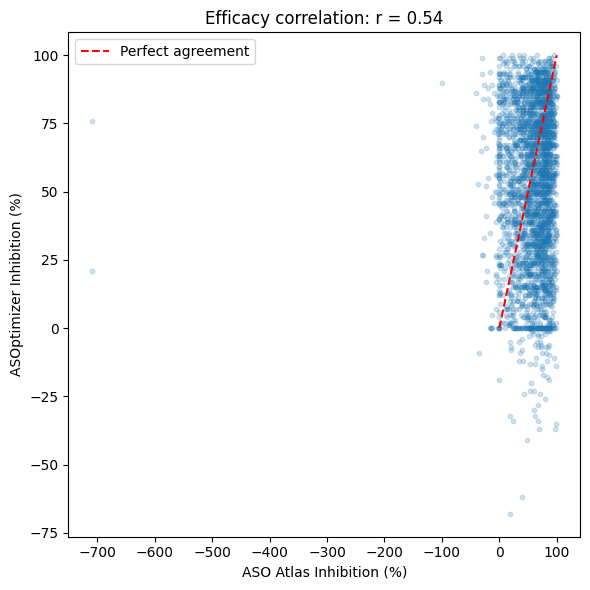


→ Correlation is moderate (r=0.54), likely due to different experimental conditions


In [4]:
atlas['seq'] = atlas['aso_sequence_5_to_3'].str.upper()
asopt['seq'] = asopt['Sequence'].str.upper()
merged = atlas.merge(asopt, on='seq')

corr = merged['inhibition_percent'].corr(merged['Inhibition(%)'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(merged['inhibition_percent'].sample(3000), merged['Inhibition(%)'].sample(3000), alpha=0.2, s=10)
ax.plot([0, 100], [0, 100], 'r--', label='Perfect agreement')
ax.set_xlabel('ASO Atlas Inhibition (%)')
ax.set_ylabel('ASOptimizer Inhibition (%)')
ax.set_title(f'Efficacy correlation: r = {corr:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n→ Correlation is moderate (r={corr:.2f}), likely due to different experimental conditions")

---
## Q4: What's missing in ASO Atlas for ASOptimizer?

**Answer: SMILES molecular structures.**

In [5]:
print("ASO Atlas chemistry format (position-based):")
print(f"  {atlas['chemistry'].iloc[0]}")
print(f"\nASOptimizer chemistry format (SMILES):")
print(f"  Pattern: {asopt['Chemical_Pattern'].iloc[0]}")
print(f"  SMILES:  {asopt['Smiles'].iloc[0][:80]}...")

ASO Atlas chemistry format (position-based):
  length=20 modifications=[Modification(modification='MOE', type='sugar', positions=[1, 2, 3, 4, 5, 16, 17, 18, 19, 20]), Modification(modification='PS', type='backbone', positions=[1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19])]

ASOptimizer chemistry format (SMILES):
  Pattern: CCCddddddddddCCC
  SMILES:  Cc1cn([C@H]2C[C@H](OP(=O)([S-])[O]C[C@H]3O[C@@H](n4cnc5c(=O)[nH]c(N)nc54)C[C@@H]...


---
## Q5: Can the gap be bridged?

**Answer: Yes.** ASO Atlas has position-level modification data that can be converted to SMILES.

In [6]:
# Parse an ASO Atlas chemistry entry
example = atlas['chemistry'].iloc[0]
print("ASO Atlas encodes:")
print(f"  • Sequence: {atlas['aso_sequence_5_to_3'].iloc[0]}")
print(f"  • Modification type: MOE (2'-O-methoxyethyl)")
print(f"  • Wing positions: 1-5 and 16-20 (5-10-5 gapmer)")
print(f"  • Backbone: phosphorothioate (PS)")
print(f"\n→ This is SUFFICIENT to generate SMILES with RDKit")
print(f"→ Each nucleotide + modification has a known SMILES structure")

ASO Atlas encodes:
  • Sequence: GCAGATATTTCAATATACAG
  • Modification type: MOE (2'-O-methoxyethyl)
  • Wing positions: 1-5 and 16-20 (5-10-5 gapmer)
  • Backbone: phosphorothioate (PS)

→ This is SUFFICIENT to generate SMILES with RDKit
→ Each nucleotide + modification has a known SMILES structure


---
## Decision Summary

| Question | Answer |
|----------|--------|
| Same measurement? | ✅ Yes - both measure % inhibition |
| Significant overlap? | ✅ Yes - 13,779 shared sequences |
| Values agree? | ⚠️ Moderate - r=0.54 correlation |
| Can use directly? | ❌ No - missing SMILES |
| Can convert? | ✅ Yes - position data → SMILES |

### Recommendation

**YES, ASO Atlas can augment ASOptimizer training**, but requires:

1. **SMILES generation** from sequence + modification positions (use RDKit)
2. **Chemical pattern extraction** (e.g., `MMMMMddddddddddMMMMM` from positions)

This would expand training data from ~37K to ~190K+ records.

In [7]:
# Quick stats summary
print("="*50)
print("BOTTOM LINE")
print("="*50)
print(f"\nASO Atlas adds {len(atlas_seqs - asopt_seqs):,} NEW sequences")
print(f"That's a {len(atlas_seqs - asopt_seqs)/len(asopt_seqs)*100:.0f}% increase in training data")
print(f"\nNext step: Write SMILES conversion script using RDKit")

BOTTOM LINE

ASO Atlas adds 151,776 NEW sequences
That's a 981% increase in training data

Next step: Write SMILES conversion script using RDKit
